In [98]:
import numpy as np
import matplotlib.pyplot as plt

# Problem 1

Define the maze and parameters

In [ ]:
reward = np.zeros((20, 20))

wall = -0.8
bump = -10
oil = -5
goal = 300
# surrounding
reward[:, 0] = wall
reward[0, :] = wall
reward[:, 19] = wall
reward[19, :] = wall

#first row
reward[1, 11:13] = bump
# 2nd row
reward[2, 1:4] = bump; reward[2, 8] = oil; reward[2, 16] = oil
# 3rd row
reward[3, 13] = goal
# 4th row
reward[4, 2] = oil; reward[4, 3:17] = wall
# 3rd and 5th columns
reward[4:8, 3] = wall; reward[2:5, 5] = wall
# 5th row
reward[5, 1] = bump; reward[5, 6] = oil; reward[5, 9] = bump
# 6th, 9th, 15th, and 17th columns
reward[6:13, 6] = wall; reward[6:11, 9] = wall; reward[6:12, 15]=wall; reward[5:9, 17]=bump
# 7th row
reward[7, 2] = bump; reward[7, 10:12] = bump; reward[7, 12:16]=wall
# 10th row
reward[10, 1:5] = wall; reward[10, 18] = oil
# 7th, 10th, 13th, 17th columns
reward[12:16, 7] = wall; reward[10:15, 10] = wall; reward[15:17, 10] = oil; reward[11:16, 13] = wall; reward[11:14, 17] = wall
# 11th row
reward[11, 15:18] = wall
# 12th row
reward[12, 3:8] = wall; reward[12, 11:13] = bump
# 14th row
reward[14, 1:3] = bump
# 15th row
reward[15, 17:19] = bump; reward[15, 13:17] = wall
# 16th row
reward[16, 7] = bump
# 17th row
reward[17, 1:3] = wall; reward[17, 7:13] = wall; reward[17, 14] = oil; reward[17, 17] = oil
# 18th row
reward[18, 7] = oil

reward


array([[ -0.8,  -0.8,  -0.8,  -0.8,  -0.8,  -0.8,  -0.8,  -0.8,  -0.8,
         -0.8,  -0.8,  -0.8,  -0.8,  -0.8,  -0.8,  -0.8,  -0.8,  -0.8,
         -0.8,  -0.8],
       [ -0.8,   0. ,   0. ,   0. ,   0. ,   0. ,   0. ,   0. ,   0. ,
          0. ,   0. , -10. , -10. ,   0. ,   0. ,   0. ,   0. ,   0. ,
          0. ,  -0.8],
       [ -0.8, -10. , -10. , -10. ,   0. ,  -0.8,   0. ,   0. ,  -5. ,
          0. ,   0. ,   0. ,   0. ,   0. ,   0. ,   0. ,  -5. ,   0. ,
          0. ,  -0.8],
       [ -0.8,   0. ,   0. ,   0. ,   0. ,  -0.8,   0. ,   0. ,   0. ,
          0. ,   0. ,   0. ,   0. , 300. ,   0. ,   0. ,   0. ,   0. ,
          0. ,  -0.8],
       [ -0.8,   0. ,  -5. ,  -0.8,  -0.8,  -0.8,  -0.8,  -0.8,  -0.8,
         -0.8,  -0.8,  -0.8,  -0.8,  -0.8,  -0.8,  -0.8,  -0.8,   0. ,
          0. ,  -0.8],
       [ -0.8, -10. ,   0. ,  -0.8,   0. ,   0. ,  -5. ,   0. ,   0. ,
        -10. ,   0. ,   0. ,   0. ,   0. ,   0. ,   0. ,   0. , -10. ,
          0. ,  -0.8],
       [ -

In [ ]:
state_matrix = np.zeros((20, 20), dtype=int)
counter = 1

for i in range(20):
    for j in range(20):
        if reward[i, j] != wall:
            state_matrix[i, j] = counter
            counter += 1
state_matrix

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0],
       [  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,
         13,  14,  15,  16,  17,  18,   0],
       [  0,  19,  20,  21,  22,   0,  23,  24,  25,  26,  27,  28,  29,
         30,  31,  32,  33,  34,  35,   0],
       [  0,  36,  37,  38,  39,   0,  40,  41,  42,  43,  44,  45,  46,
         47,  48,  49,  50,  51,  52,   0],
       [  0,  53,  54,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,  55,  56,   0],
       [  0,  57,  58,   0,  59,  60,  61,  62,  63,  64,  65,  66,  67,
         68,  69,  70,  71,  72,  73,   0],
       [  0,  74,  75,   0,  76,  77,   0,  78,  79,   0,  80,  81,  82,
         83,  84,   0,  85,  86,  87,   0],
       [  0,  88,  89,   0,  90,  91,   0,  92,  93,   0,  94,  95,   0,
          0,   0,   0,  96,  97,  98,   0],
       [  0,  99, 100, 101, 102, 103,   0, 104, 105,   0, 106, 1

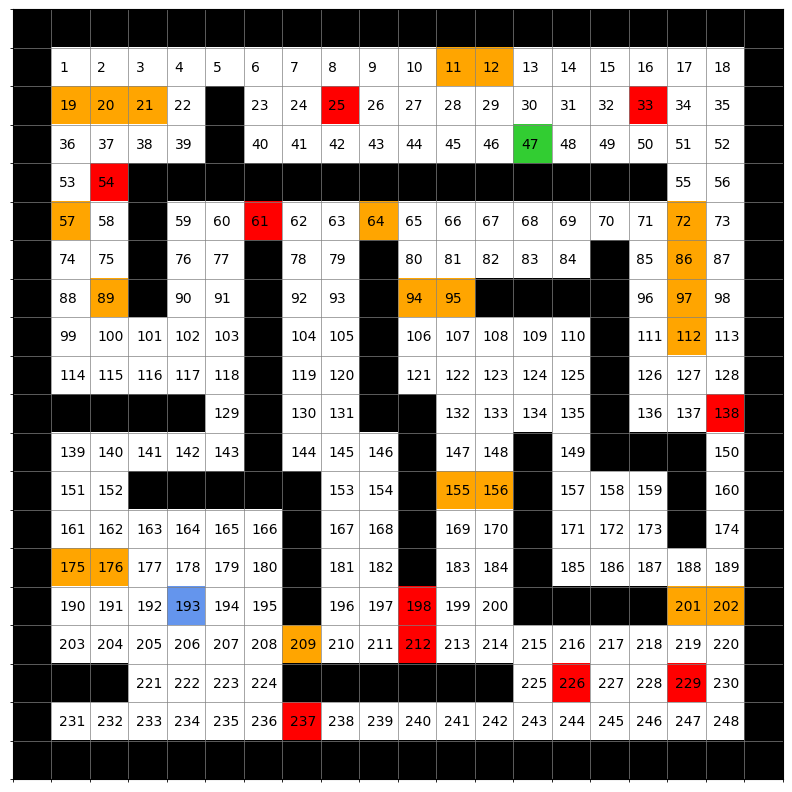

In [ ]:
mapped_maze = np.zeros_like(reward)
mapped_maze[reward == -0.8] = 1  # Wall -> Black
mapped_maze[reward == -10] = 2   # Bump -> Orange
mapped_maze[reward == -5] = 3    # Oil -> Red
mapped_maze[reward == 300] = 4   # Goal -> Green
mapped_maze[15, 4] = 5 # Start -> Blue


cmap = plt.matplotlib.colors.ListedColormap(["white", "black", "orange", "red", "limegreen", "cornflowerblue"])

# Plot the reward with grid lines
fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(mapped_maze, cmap=cmap, origin="upper")

# Set grid lines
ax.set_xticks(np.arange(-0.5, 20, 1), minor=True)
ax.set_yticks(np.arange(-0.5, 20, 1), minor=True)
ax.grid(which="minor", color="gray", linestyle='-', linewidth=0.5)

for s in np.nditer(state_matrix[state_matrix!=0]):
    i = np.where(state_matrix==s)[0][0]
    j = np.where(state_matrix==s)[1][0]

    plt.text(j-0.3, i+0.1, str(int(s)), )

# Hide axis ticks
ax.set_xticks([])
ax.set_yticks([])

plt.show()

In [117]:
def probability(s1, s2, a, p=0.025):
    if a == 'U':
        if (s2[0] == s1[0]-1) & (s2[1] == s1[1]):
            return 1-p
        elif (s2[0] == s1[0]) & (abs(s1[1]-s2[1]) == 1):
            return p/2
        else:
            return 0
    elif a == 'D':
        if (s2[0] == s1[0]+1) & (s2[1] == s1[1]):
            return 1-p
        elif (s2[0] == s1[0]) & (abs(s1[1]-s2[1]) == 1):
            return p/2
        else:
            return 0
    elif a == 'R':
        if (s2[1] == s1[1]+1) & (s2[0] == s1[0]):
            return 1-p
        elif (s2[1] == s1[1]) & (abs(s1[0]-s2[0]) == 1):
            return p/2
        else:
            return 0
    elif a == 'L':
        if (s2[1] == s1[1]-1) & (s2[0] == s1[0]):
            return 1-p
        elif (s2[1] == s1[1]) & (abs(s1[0]-s2[0]) == 1):
            return p/2
        else:
            return 0
    else:
        return np.nan
    
# function validation
s1 = [np.where(state_matrix==47)[0][0], np.where(state_matrix==47)[1][0]]
s2 = [np.where(state_matrix==46)[0][0], np.where(state_matrix==46)[1][0]]
probability(s1, s2, a='L')

0.975

# Section 1: Policy Iteration

Define policy evaluation function

In [ ]:
policy = np.array(['L']*248)
def policy_evaluation(policy, v0 = np.zeros((248, )), gamma = 0.99, theta = 0.01, p = 0.025):
    iteration = 0
    
    while True:
        iteration +=1
        v = np.zeros((248, ))
        
        for s in np.nditer(state_matrix[state_matrix!=0]):
            row = np.where(state_matrix==s)[0][0]
            col = np.where(state_matrix==s)[1][0]
            s1 = [row, col]
            
            a = policy[s-1]
            if reward[row, col] == goal:
                v[s-1] = 0
            else:
                for i in range(row-1, row+2):
                    for j in range(col-1, col+2):
                        R = reward[i, j] - 1
                        if reward[i, j] == wall:
                            s2 = s1
                        else:
                            s2 = [i, j]
                        
                        s_prime = state_matrix[s2[0], s2[1]]-1
                        v[s-1] += probability(s1, [i, j], a, p)*(R+gamma*v0[s_prime])

        if max(abs(v0-v)) > theta:
            v0=v
        else:
            break
        
    return v


Define policy improvement function

In [ ]:
def improve_policy(prev_policy, gamma=0.99):
    v = policy_evaluation(prev_policy, gamma=gamma)
    actions = ['U', 'D', 'L', 'R']
    state_policy_v = np.zeros((248, 4))
    Q_val = []
    for s in np.nditer(state_matrix[state_matrix!=0]):
            row = np.where(state_matrix==s)[0][0]
            col = np.where(state_matrix==s)[1][0]
            s1 = [row, col]
            
            for a in range(len(actions)):
                for i in range(row-1, row+2):
                    for j in range(col-1, col+2):
                        R = reward[i, j] - 1
                        if reward[i, j] == wall:
                            s2 = s1
                        else:
                            s2 = [i, j]
                        

                        state_policy_v[s-1, a] += probability(s1, [i, j], actions[a])*(R+gamma*v[state_matrix[s2[0], s2[1]]-1])
            Q_val.append(actions[np.argmax(state_policy_v[s-1])])
    return np.array(Q_val)

new_policy = improve_policy(policy)

Combine policy evaluation and improvement to obtain policy iteration function

In [11]:
def policy_iteration(prev_policy, v0, gamma, theta, p):
    iteration=0
    new_policy = prev_policy
    while (any(new_policy!= prev_policy) or (iteration==0)):
        prev_policy = new_policy
        v = policy_evaluation(prev_policy, v0=v0, gamma=gamma, theta=theta, p=p)
        v0=v
        
        new_policy = improve_policy(prev_policy, gamma=gamma)
        
        iteration+=1
    print(iteration)
    return new_policy, v



Estimate the optimal value vector and optimal policy vector for three given scenarios, and print the number of policy iteration required before convergence.

In [12]:
optimal_policy_1, optimal_value_func_1 = policy_iteration(prev_policy = np.array(['L']*248), v0 = np.zeros((248, )), gamma=0.99, theta=0.01, p=0.025)
optimal_policy_2, optimal_value_func_2 = policy_iteration(prev_policy = np.array(['L']*248), v0 = np.zeros((248, )), gamma=0.99, theta=0.01, p=0.4)
optimal_policy_3, optimal_value_func_3 = policy_iteration(prev_policy = np.array(['L']*248), v0 = np.zeros((248, )), gamma=0.5, theta=0.01, p=0.025)

17
17
7


In [109]:
# Save the results to avoid unnessecary computations

# np.save('optimal_policy_1.npy', optimal_policy_1)
# np.save('optimal_policy_2.npy', optimal_policy_2)
# np.save('optimal_policy_3.npy', optimal_policy_3)
# np.save('optimal_value_func_1.npy', optimal_value_func_1)
# np.save('optimal_value_func_2.npy', optimal_value_func_2)
# np.save('optimal_value_func_3.npy', optimal_value_func_3)

optimal_policy_1 = np.load('optimal_policy_1.npy')
optimal_policy_2 = np.load('optimal_policy_2.npy')
optimal_policy_3 = np.load('optimal_policy_3.npy')
optimal_value_func_1 = np.load('optimal_value_func_1.npy')
optimal_value_func_2 = np.load('optimal_value_func_2.npy')
optimal_value_func_3 = np.load('optimal_value_func_3.npy')

Plot the optimal policy for all states

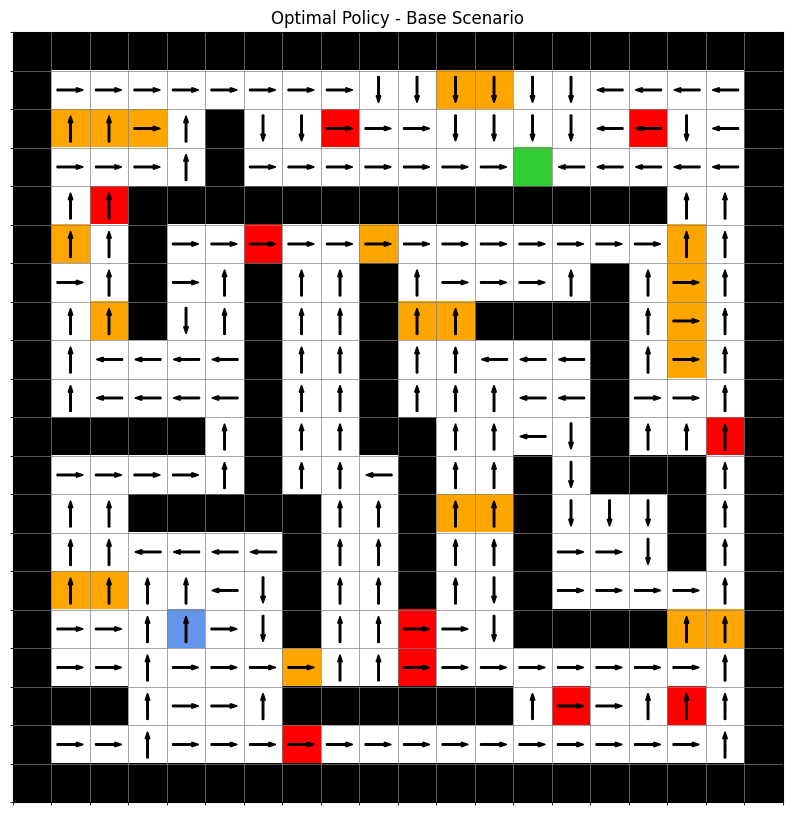

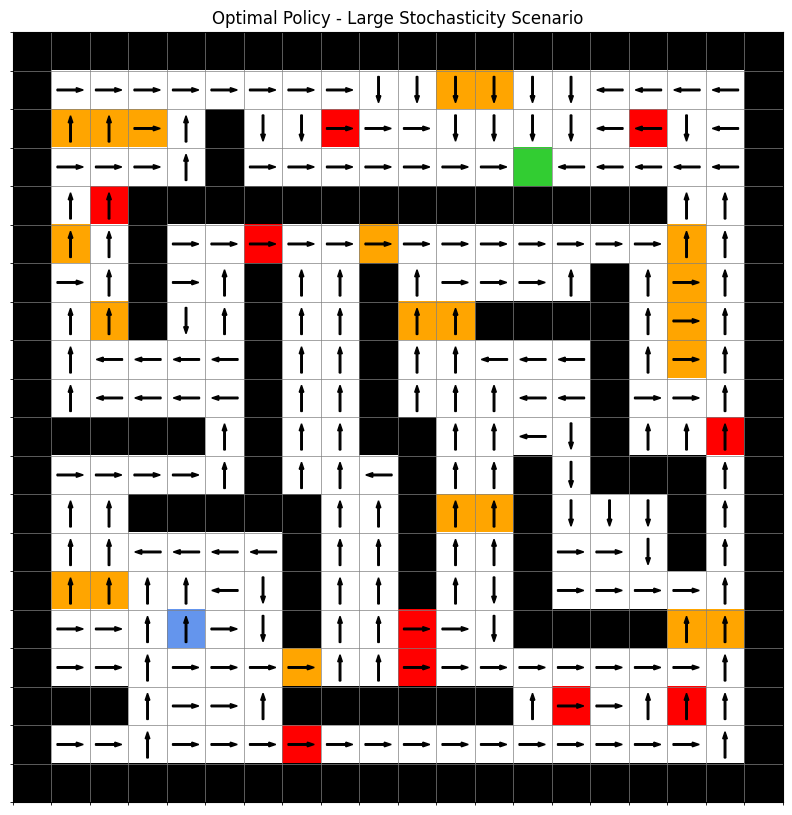

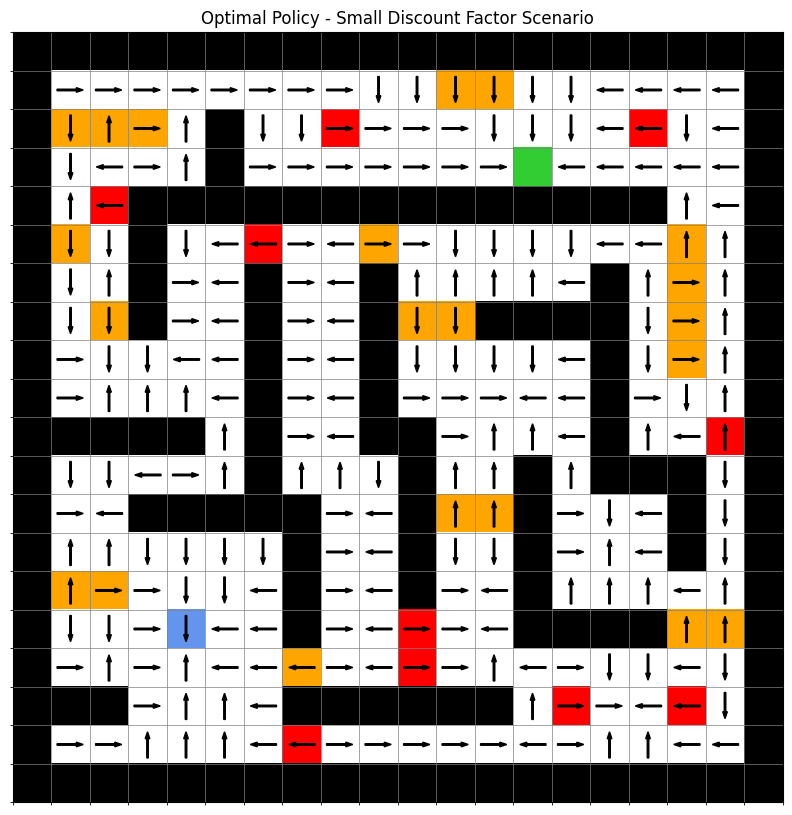

In [ ]:
def plot_policy(policy, title='Optimal Policy'):
    cmap = plt.matplotlib.colors.ListedColormap(["white", "black", "orange", "red", "limegreen", "cornflowerblue"])

    # Plot the reward with grid lines
    fig, ax = plt.subplots(figsize=(10, 10))
    ax.imshow(mapped_maze, cmap=cmap, origin="upper")

    # Set grid lines
    ax.set_xticks(np.arange(-0.5, 20, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, 20, 1), minor=True)
    ax.grid(which="minor", color="gray", linestyle='-', linewidth=0.5)

    # Hide axis ticks
    ax.set_xticks([])
    ax.set_yticks([])

        
    for s in np.nditer(state_matrix[(state_matrix!=0) & (state_matrix!=47)]):
        i = np.where(state_matrix==s)[0][0]
        j = np.where(state_matrix==s)[1][0]
        if policy[s-1] == "U":
            plt.arrow(j, i+0.35, 0, -0.5, width=0.04, color='black')  # Up
        elif policy[s-1] == "R":
            plt.arrow(j-0.35, i, 0.5, 0, width=0.04, color='black')  # Right
        elif policy[s-1] == "D":
            plt.arrow(j, i-0.35, 0, 0.50, width=0.04, color='black')  # Down
        else:
            plt.arrow(j+0.35, i, -0.5, 0, width=0.04, color='black')  # Left
    plt.title(title)
    plt.show()
    return

plot_policy(optimal_policy_1, title = 'Optimal Policy - Base Scenario')
plot_policy(optimal_policy_2, title = 'Optimal Policy - Large Stochasticity Scenario')
plot_policy(optimal_policy_3, title = 'Optimal Policy - Small Discount Factor Scenario')

Plot the optimal values for all the states

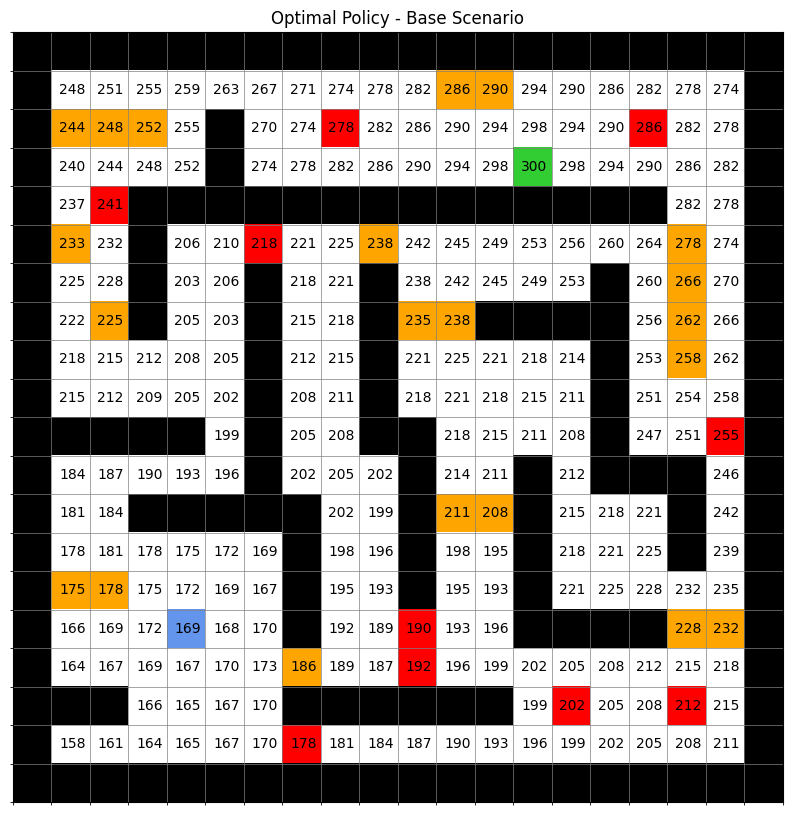

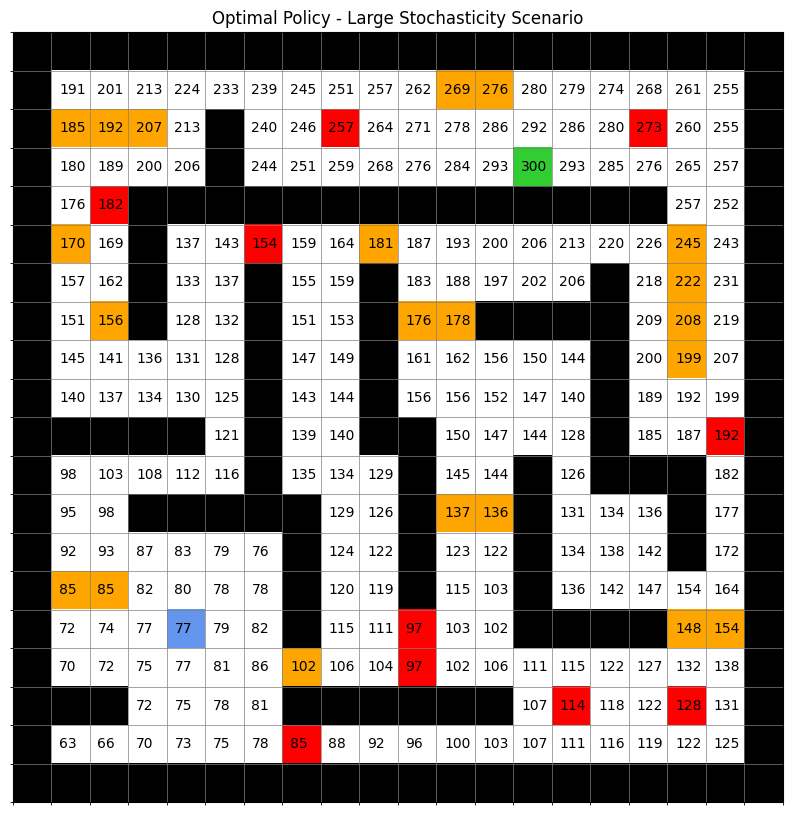

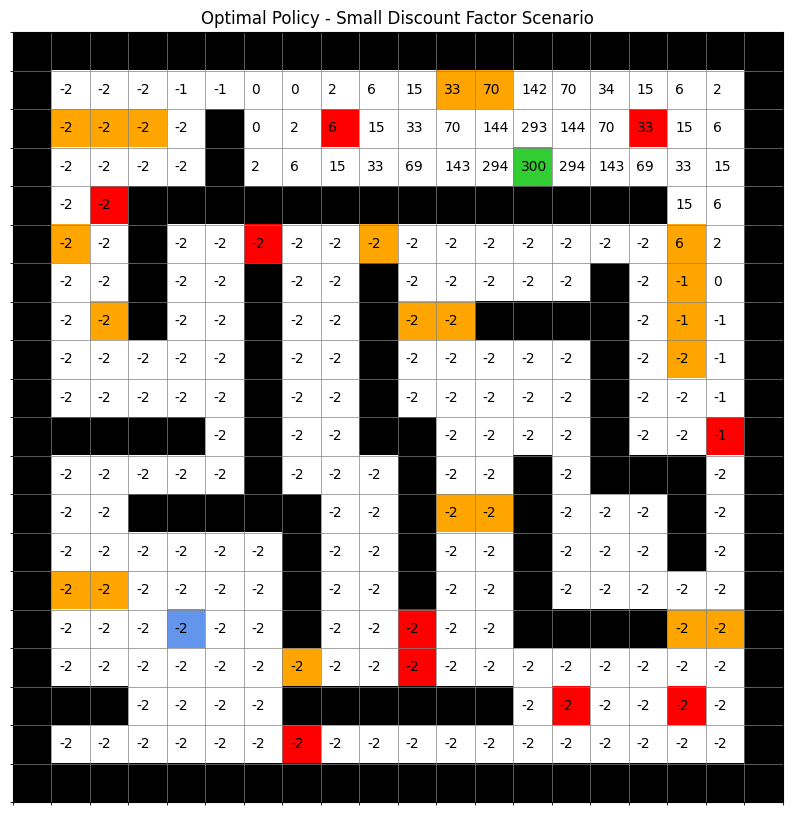

In [ ]:
def plot_values(value_func, title = 'Optimal Values'):
    cmap = plt.matplotlib.colors.ListedColormap(["white", "black", "orange", "red", "limegreen", "cornflowerblue"])

    # Plot the reward with grid lines
    fig, ax = plt.subplots(figsize=(10, 10))
    ax.imshow(mapped_maze, cmap=cmap, origin="upper")

    # Set grid lines
    ax.set_xticks(np.arange(-0.5, 20, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, 20, 1), minor=True)
    ax.grid(which="minor", color="gray", linestyle='-', linewidth=0.5)

    # Hide axis ticks
    ax.set_xticks([])
    ax.set_yticks([])

        
    for s in np.nditer(state_matrix[state_matrix!=0]):
        i = np.where(state_matrix==s)[0][0]
        j = np.where(state_matrix==s)[1][0]
        if s == 47:
            plt.text(j-0.3, i+0.1, str(int(goal)), )
        else:
            plt.text(j-0.3, i+0.1, str(int(value_func[s-1])), )
    plt.title(title)
    plt.show()

plot_values(optimal_value_func_1, title = 'Optimal Policy - Base Scenario')
plot_values(optimal_value_func_2, title = 'Optimal Policy - Large Stochasticity Scenario')
plot_values(optimal_value_func_3, title = 'Optimal Policy - Small Discount Factor Scenario')

Plot the optimal path for three given scenarios

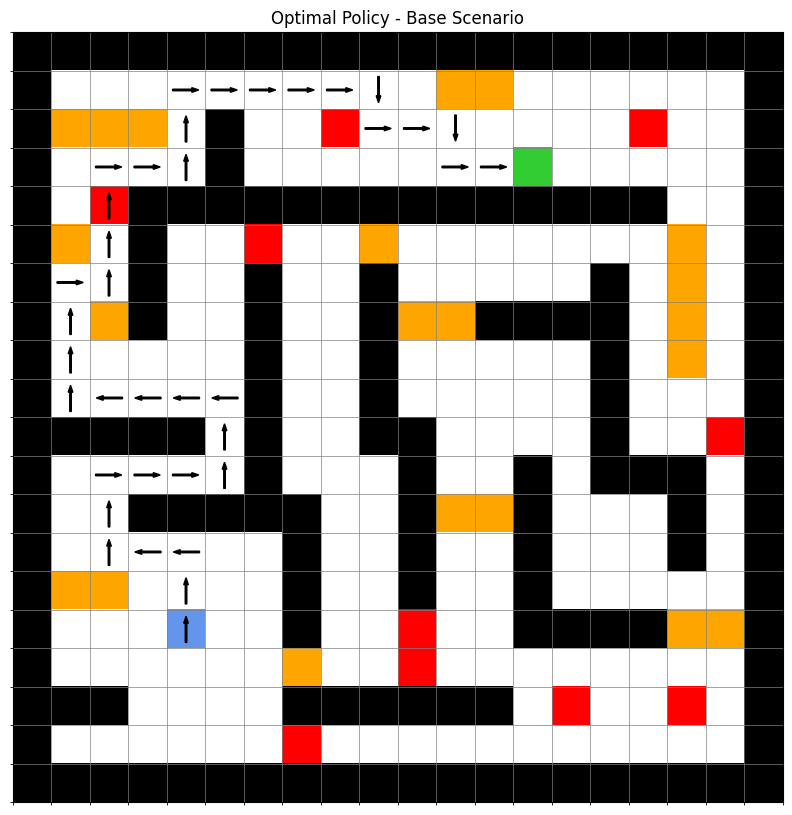

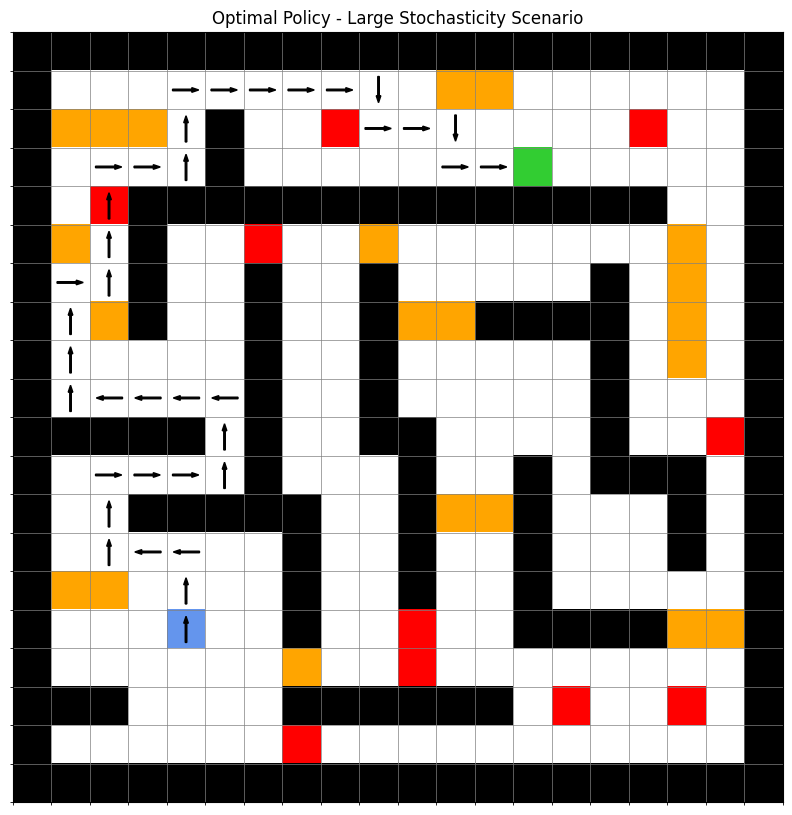

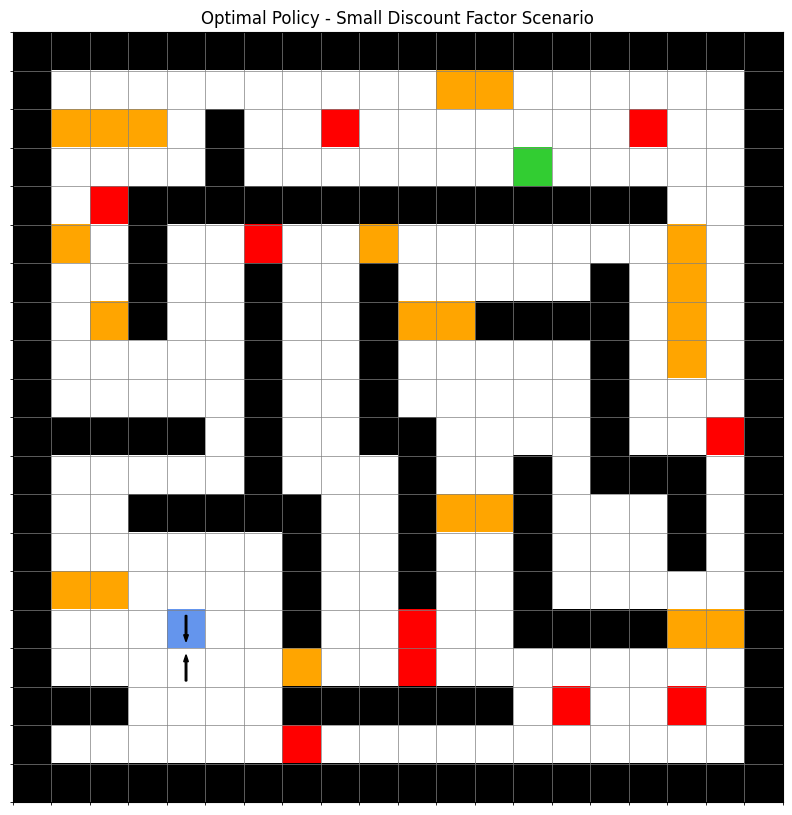

In [ ]:
def plot_path(policy, s=[15, 4], title='Optimal Path'):
    cmap = plt.matplotlib.colors.ListedColormap(["white", "black", "orange", "red", "limegreen", "cornflowerblue"])

    # Plot the reward with grid lines
    fig, ax = plt.subplots(figsize=(10, 10))
    ax.imshow(mapped_maze, cmap=cmap, origin="upper")

    # Set grid lines
    ax.set_xticks(np.arange(-0.5, 20, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, 20, 1), minor=True)
    ax.grid(which="minor", color="gray", linestyle='-', linewidth=0.5)

    # Hide axis ticks
    ax.set_xticks([])
    ax.set_yticks([])
    
    i = s[0]; j=s[1]
    s = state_matrix[i, j]
    memory = [s]

    while s!= 47:
        
        if policy[s-1] == "U":
            plt.arrow(j, i+0.35, 0, -0.5, width=0.04, color='black')  # Up
            i -= 1
        elif policy[s-1] == "R":
            plt.arrow(j-0.35, i, 0.5, 0, width=0.04, color='black')  # Right
            j += 1
        elif policy[s-1] == "D":
            plt.arrow(j, i-0.35, 0, 0.50, width=0.04, color='black')  # Down
            i += 1
        else:
            plt.arrow(j+0.35, i, -0.5, 0, width=0.04, color='black')  # Left
            j -= 1
        s = state_matrix[i, j]
        if s in memory:
            break
        else:
            memory.append(s)
    plt.title(title)
    plt.show()

plot_path(optimal_policy_1, title = 'Optimal Policy - Base Scenario')
plot_path(optimal_policy_2, title = 'Optimal Policy - Large Stochasticity Scenario')
plot_path(optimal_policy_3, title = 'Optimal Policy - Small Discount Factor Scenario')

# Section 2: Value Iteration

In [ ]:
def value_iteration(theta=0.01, gamma=0.99, v0=np.zeros((248, )), actions=['U', 'D', 'L', 'R'], p=0.025):
    iteration = 0
    
    while True:
        iteration +=1
        v = np.zeros((248, ))
        optimal_policy = np.array(['L']*248)
        actionV = np.zeros((248, 4))
        for s in np.nditer(state_matrix[state_matrix!=0]):
            row = np.where(state_matrix==s)[0][0]
            col = np.where(state_matrix==s)[1][0]
            s1 = [row, col]

            if reward[row, col] == goal:
                v[s-1] = 0
            else:
                
                for a in range(len(actions)):
                    for i in range(row-1, row+2):
                        for j in range(col-1, col+2):
                            R = reward[i, j] - 1
                            if reward[i, j] == wall:
                                s2 = s1
                            else:
                                s2 = [i, j]
                            
                            s_prime = state_matrix[s2[0], s2[1]]-1
                            actionV[s-1, a] += probability(s1, [i, j], actions[a], p)*(R+gamma*v0[s_prime])
                v[s-1] = max(actionV[s-1])
        if max(abs(v0-v)) > theta:
            v0=v
        else:
            for s in np.nditer(state_matrix[state_matrix!=0]):
                optimal_policy[s-1] = actions[np.argmax(actionV[s-1])]
            break

    return iteration, v, optimal_policy

52


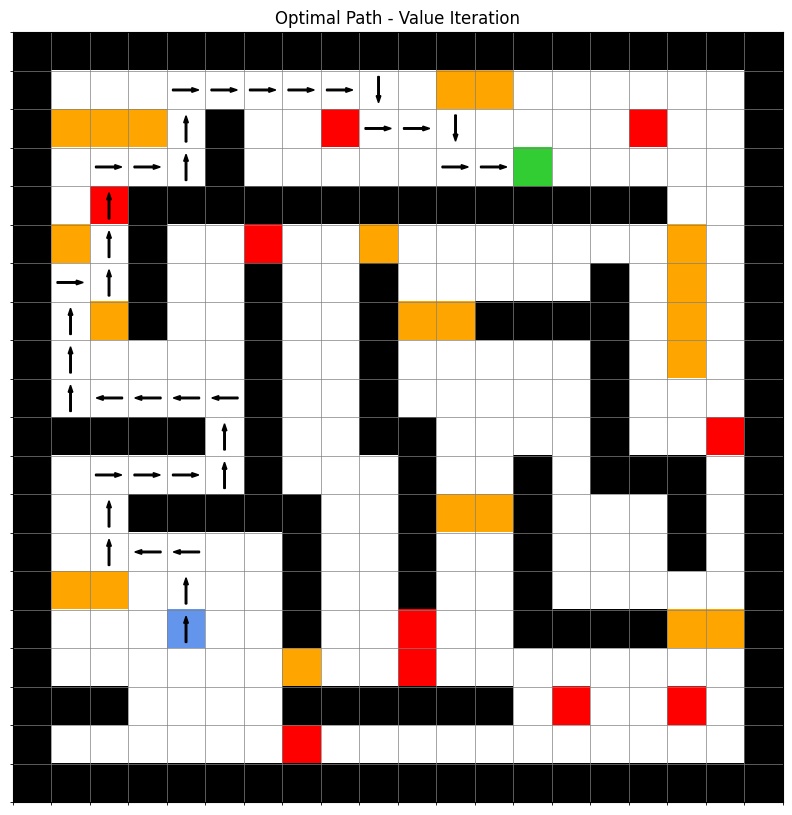

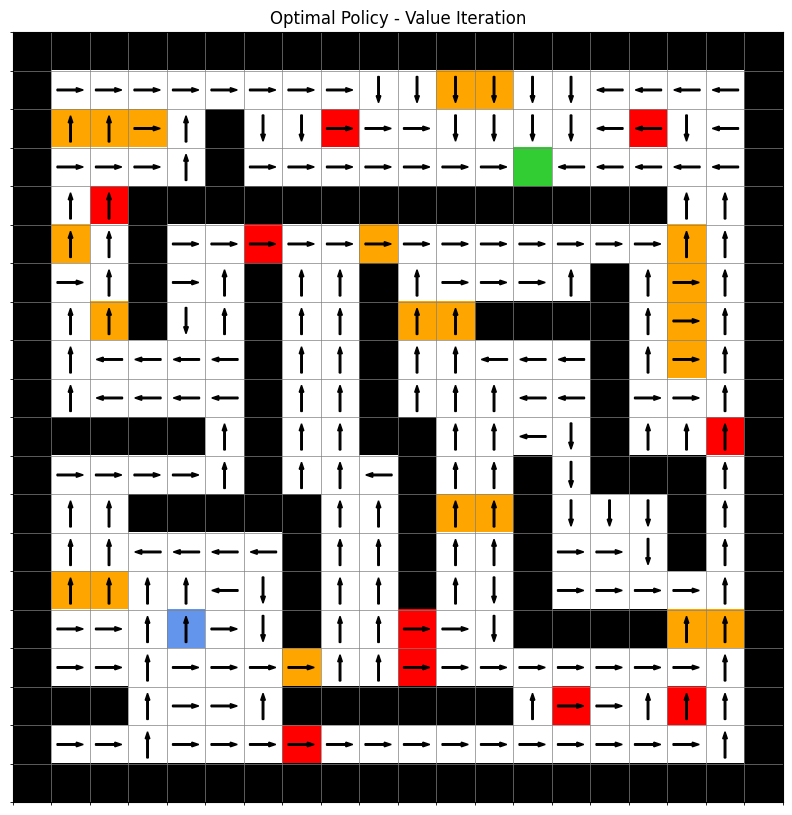

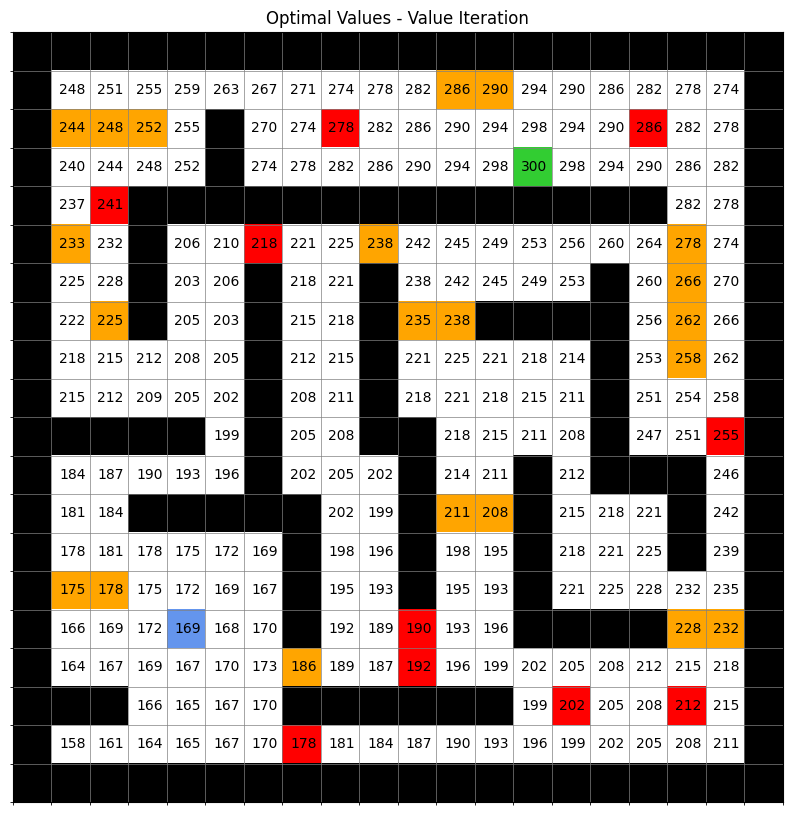

In [121]:
iteration, VI_values, VI_policy = value_iteration()
print(iteration)
plot_path(VI_policy, title = 'Optimal Path - Value Iteration')
plot_policy(VI_policy, title = 'Optimal Policy - Value Iteration')
plot_values(VI_values, title = 'Optimal Values - Value Iteration')

# Problem 2

In [2]:
import numpy as np
import random

Part (a)

In [19]:
# Define Parameters
C = np.array([[0, 0, -1, 0], [1, 0, -1, -1], [0, 1, 0, 0], [-1, 1, 1, 0]])
A = [np.array([0,0,0,0]), np.array([1,0,0,0]), np.array([0,1,0,0]), np.array([0,0,1,0]), np.array([0,0,0,1])]

def Reward(S, a):
    return np.dot(np.array([5, 5, 5, 5]), S.T) - np.sum(a)


In [20]:
def transition_matrices(p, A=A, C=C):
    action_mat = np.zeros((5, 16, 16))
    for n in range(5):
        a = A[n]
        for i in range(16):
            s_i = np.array(list(map(int, format(i, '04b'))))
            for j in range(16):
                s_j = np.array(list(map(int, format(j, '04b'))))
                val = np.sum(abs(s_j - np.bitwise_xor((np.dot(C, s_i.T)>0), a)))
                action_mat[n, i, j] = p**(val)*(1-p)**(4-val)

    return action_mat



In [81]:
def DP_value_iteration(p, v0 = np.zeros((16, 1)), theta = 0.01, gamma=0.95):
    iteration = 0
    
    while True:
        iteration +=1
        v = np.zeros((16, 1))
        optimal_policy = np.zeros(16, dtype=np.int64)
        actionV = np.zeros((16, 5))
        for a in range(len(A)):
            transition_matrix = transition_matrices(p=p)[a]
            R_ssa = np.zeros((16, 16))
            for i in range(16):
                # s_i = np.array(list(map(int, format(i, '04b'))))
                for j in range(16):
                    s_j = np.array(list(map(int, format(j, '04b'))))
                    R_ssa[i, j] = Reward(s_j, A[a])
                    
            R_sa = np.dot(transition_matrix * R_ssa, np.ones((16, 1)))
            
            actionV[:, a] = (R_sa + gamma*(transition_matrix @ v0)).flatten()
        for n in range(16):
            v[n] = max(actionV[n])
        if max(abs(v0-v)) > theta:
            v0=v
        else:
            for n in range(16):
                optimal_policy[n] = np.argmax(actionV[n])
            break

    return iteration, v, optimal_policy


In [145]:
iterations, optimal_values, optimal_policy = DP_value_iteration(p=0.04)
print(iterations)
print(optimal_values)
print(optimal_policy+1)

142
[[258.3586195 ]
 [258.3586195 ]
 [262.80424337]
 [262.80424337]
 [267.70118076]
 [267.70118076]
 [267.70118076]
 [267.70118076]
 [263.1076131 ]
 [258.3586195 ]
 [258.3586195 ]
 [258.3586195 ]
 [267.70118076]
 [263.1076131 ]
 [267.70118076]
 [267.70118076]]
[3 3 3 3 3 3 3 3 4 3 3 3 5 3 3 3]


In [147]:
def activation_rate(p, policy=optimal_policy, steps = 200, episodes = 100, C=C, A=A):
    initial_states = [random.randint(0, 15) for x in range(episodes)]
    states = [np.array(list(map(int, format(k, '04b')))) for k in range(16)]
    episode_activation = []
    for n in initial_states:
        s0 = states[n]
        trajectory = [s0]
        
        for i in range(steps):
            action = A[policy[n]]
            noise = random.choices([0, 1], weights=[1-p, p], k=4)
            s1 = np.bitwise_xor(np.bitwise_xor((np.dot(C, s0)>0), action), noise)
            trajectory.append(s1)
            s1=s0
        episode_activation.append(np.average([np.sum(z) for z in trajectory]))
        # print(len(episode_activation))
    return np.average(episode_activation)


In [153]:
print(activation_rate(0.04, policy = optimal_policy))
print(activation_rate(0.04, policy = np.zeros((16, ), dtype=np.int64)))

2.1293532338308463
1.075273631840796


Part (b)

In [ ]:
iteration_b1, optimal_value_b1, optimal_policy_b1 = DP_value_iteration(p=0.15)
iteration_b2, optimal_value_b2, optimal_policy_b2 = DP_value_iteration(p=0.48)


In [157]:
DP_value_iteration(p=0.48)

(136,
 array([[196.02232589],
        [196.02232589],
        [196.22032049],
        [196.22032049],
        [196.42223861],
        [196.42223861],
        [196.42223861],
        [196.42223861],
        [196.23376517],
        [196.02232589],
        [196.02232589],
        [196.02232589],
        [196.43551711],
        [196.22408975],
        [196.42223861],
        [196.42223861]]),
 array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]))

In [26]:
print(activation_rate(p=0.15, policy = optimal_policy_b1))
print(activation_rate(p=0.48, policy = optimal_policy_b2))

2.0793532338308456
1.964626865671642


Part (c)

In [96]:
def DP_policy_iteration(p, pi0 = np.zeros((16,), dtype=np.int64), gamma=0.95):
    iteration = 0
    
    while True:
        iteration +=1
        v_pi = np.zeros((16, 1))
        transition_matrix_pi = np.zeros((16, 16))
        R_sspi = np.zeros((16, 16))
        actionV = np.zeros((16, 5))
        for i in range(16):
            # s_i = np.array(list(map(int, format(i, '04b'))))
            action = pi0[i]
            transition_matrix_pi[i] = (transition_matrices(p=p)[action])[i]
            for j in range(16):
                s_j = np.array(list(map(int, format(j, '04b'))))
                R_sspi[i, j] = Reward(s_j, A[action])
                
        R_spi = np.dot(transition_matrix_pi * R_sspi, np.ones((16, 1)))
        
        v_pi = np.dot(np.linalg.inv(np.identity(16) - gamma*transition_matrix_pi), R_spi)
        
        pi = np.zeros((16,), dtype=np.int64)
        for a in range(5):
            M_a = transition_matrices(p=p)[a]
            R_ssa = np.zeros((16, 16))
            for i in range(16):
                for j in range(16):
                    s_j = np.array(list(map(int, format(j, '04b'))))
                    R_ssa[i, j] = Reward(s_j, A[a])
            actionV[:, a] = (np.dot(M_a*R_ssa , np.ones((16, 1))) + gamma*np.dot(M_a, v_pi)).flatten()

        
        for n in range(16):
            pi[n] = np.argmax(actionV[n])
        if any(pi != pi0):
            pi0=pi.copy()
        else:
            break
    return iteration, v_pi, pi

In [158]:
iterations, optimal_values, optimal_policy = DP_policy_iteration(p=0.04)

In [159]:
import pandas as pd
import numpy as np

df = pd.DataFrame(columns=["ID", "Optimal Value", "Optimal Policy"])

for j in range(16):
    binary_array = np.array(list(map(int, format(j, '04b'))))  # Convert j to a 4-bit binary array
    df.loc[len(df)] = [f's{j+1}', optimal_values[j][0], f'a{optimal_policy[j]+1}']  # Append row correctly

df



,ID,Optimal Value,Optimal Policy
0,s1,258.542413,a3
1,s2,258.542413,a3
2,s3,262.988037,a3
3,s4,262.988037,a3
4,s5,267.884974,a3
5,s6,267.884974,a3
6,s7,267.884974,a3
7,s8,267.884974,a3
8,s9,263.291407,a4
9,s10,258.542413,a3
